In [60]:
from scipy.stats import poisson, skew
import matplotlib.pyplot as plt
from sklearn.linear_model import PoissonRegressor

# Poisson Distribution

**Number of events occurring in a fixed interval of time or space**

### Mathematical Definition

$$X \sim \text{Poisson}(\lambda)$$

$$P(X = k) = \frac{e^{-\lambda} \cdot \lambda^k}{k!}$$

#### Where:
- $\lambda$ (lambda) = average number of events per interval
- $k$ = number of events (0, 1, 2, 3, ...)

#### Properties:
- Mean: $E[X] = \lambda$
- Variance: $\text{Var}(X) = \lambda$
- Support: $k \in \{0, 1, 2, 3, \ldots\}$

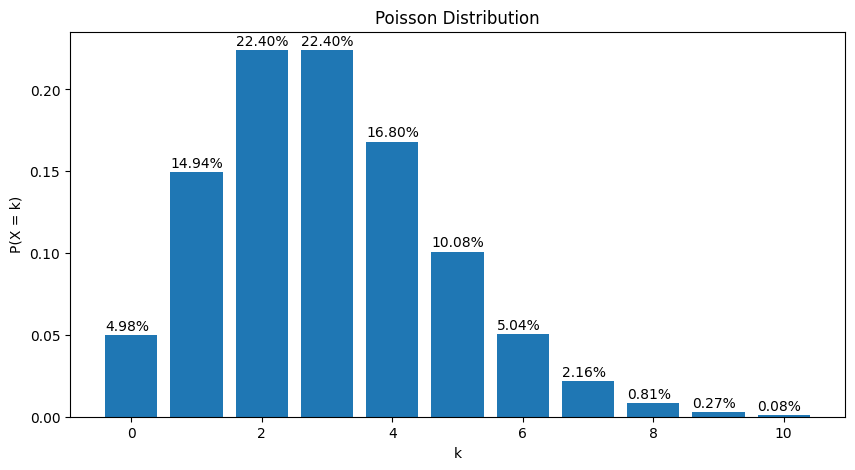

In [17]:
# λ = 3 events per interval
lambda_ = 3 # on AVERAGE, 3 customers arrive every 5 minutes
k_values = range(0, 11) # possible number of customers that could actually show up (0-10 customers)
probabilities = [poisson.pmf(k, lambda_) for k in k_values] # probability of exactly k customers arriving in a 5-minute window

plt.figure(figsize=(10, 5))
plt.bar(k_values, probabilities)
plt.xlabel('k')
plt.ylabel('P(X = k)')
plt.title(f'Poisson Distribution')


for k, p in zip(k_values, probabilities):
    plt.text(k-0.4, p+0.003, f'{p:.2%}')

plt.show()

## The Key Properties

| Property | Formula | Intuition |
|----------|---------|-----------|
| **Mean** | $\lambda$ | Average number of events |
| **Variance** | $\lambda$ | Spread = mean (equidispersion) |
| **Support** | $0, 1, 2, 3, \ldots$ | Only non-negative integers |
| **Shape** | Right-skewed (for small $\lambda$) | Few large counts, many small counts |

In [23]:
skew_ = poisson.stats(lambda_, moments='s')
print(f'{skew_}') # if skew>0.5 -> Highly right-skewed, if skew>0.2 -> Moderately right-skewed

0.5773502691896257


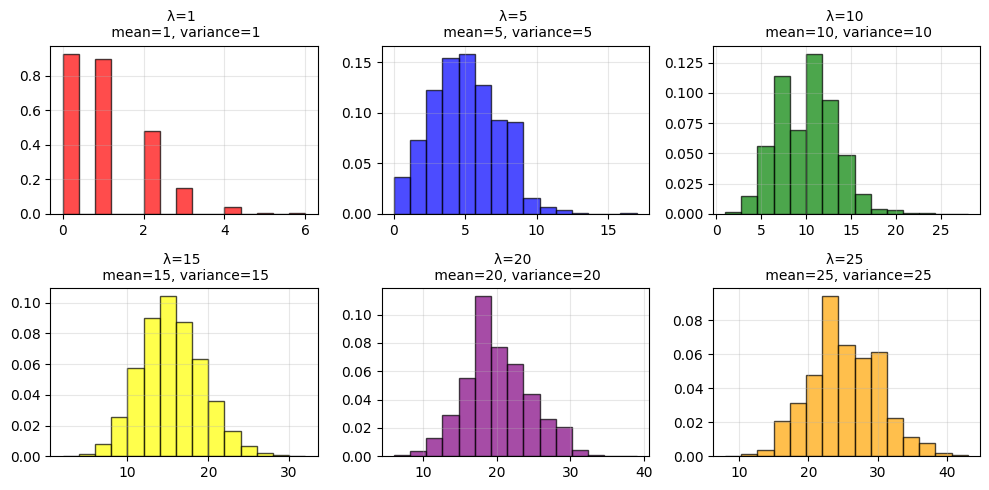

In [62]:
# lambda = mean = variance

lambda_ = [1, 5, 10, 15, 20, 25]
colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange']

plt.figure(figsize=(10, 5))

for i, lam in enumerate(lambda_):
    x = np.random.poisson(lam, size=10000)

    plt.subplot(2, 3, i+1)
    plt.hist(x, bins=15, color=colors[i], density=True, alpha=0.7, edgecolor='black')
    plt.title(f'λ={lam} \n mean={np.mean(x):0.0f}, variance={np.var(x):0.0f}', fontsize=10)
    plt.grid(alpha=0.3)

plt.tight_layout()

## When to Use Poisson

Real-world applications where Poisson is the right choice:

| Domain | Example | λ Represents |
|--------|---------|--------------|
| **E-commerce** | Number of purchases per customer per day | Average daily purchases |
| **Web Analytics** | Website visits per hour | Average hourly visits |
| **Healthcare** | ER visits per day | Average daily ER visits |
| **Manufacturing** | Defects per batch | Average defects per batch |
| **Call Centers** | Calls per minute | Average call rate |
| **Transportation** | Accidents per intersection per year | Average accident rate |
| **Finance** | Loan defaults per month | Average default rate |


## Poisson Regression (GLM)

In [63]:

# data
np.random.seed(42)
X = np.random.normal(0, 1, (1000, 3))
true_coef = [0.5, -0.3, 0.8]
log_lambda = np.dot(X, true_coef)
lambda_true = np.exp(log_lambda)
y = np.random.poisson(lambda_true)

# model
model = PoissonRegressor()
model.fit(X, y)

print(f"True coefficients: {true_coef}")
print(f"Estimated coefficients: {model.coef_.round(3)}")

# predict
y_pred = model.predict(X)
print(f"Mean prediction: {y_pred.mean():.2f}")
print(f"Mean true: {y.mean():.2f}")
print("Predictions are always positive!")

True coefficients: [0.5, -0.3, 0.8]
Estimated coefficients: [ 0.388 -0.195  0.544]
Mean prediction: 1.73
Mean true: 1.73
Predictions are always positive!
